## Wortwolken

In diesem Notebook werden wesentliche Schritte zur Erzeugung von Wortwolken aus Wikipedia-Artikeln durchgeführt. Ziel ist es zudem, vermehrt Funktionen (Def) und Klassen (class) zu bauen, die später in .py-Dateien ausgelagert werden können.

In [1]:
import wikipediaapi

### 1. Schritt: Definition zum Laden

In [2]:
def lade_wiki_texte(teams: list, sprache: str = "de") -> dict:
    wiki = wikipediaapi.Wikipedia(
        user_agent="GenSoccerAnalyzer/1.0",
        language=sprache
    )
    texte = {}
    for team in teams:
        seite = wiki.page(team)
        if seite.exists():
            texte[team] = seite.text
            print(f"✓ {team} geladen ({len(seite.text)} Zeichen)")
        else:
            print(f"✗ {team} nicht gefunden")
    return texte

In [3]:
texte = lade_wiki_texte(["FC Bayern München", "Borussia Dortmund"])

✓ FC Bayern München geladen (173624 Zeichen)
✓ Borussia Dortmund geladen (161378 Zeichen)


Für späteren Import der Def lade_wiki_texte aus einer py-Datei `laden.py`:

In [ ]:
# from laden import lade_wiki_texte
# texte = lade_wiki_texte(["FC Bayern München", "Borussia Dortmund"])

-----------------------------------

### 2. Schritt: Preprocessing

#### a) Setup & Installation

Folgende Befehle müssen einmalig im Terminal ausgeführt werden.
Vorher das Virtual Environment aktivieren:

    .venv\Scripts\activate

Dann das deutsche spaCy-Modell installieren:

    python -m spacy download de_core_news_sm

In [4]:
#
# !python -m spacy download de_core_news_sm

-------------------------------

#### Text bereinigen

**Was passiert hier?**
Der rohe Wikipedia-Text wird bereinigt: Kleinschreibung, Sonderzeichen entfernen, Stopwörter rausfiltern.

**Voraussetzung:** spaCy + de_core_news_sm installiert (siehe Setup oben)

In [5]:
import spacy
nlp = spacy.load("de_core_news_sm")

def bereinige_und_tokenisiere(text: str) -> list:
    doc = nlp(text)
    return [
        token.lemma_.lower()
        for token in doc
        if not token.is_stop
        and not token.is_punct
        and len(token.text) > 2
    ]

#### Aufruf:

In [7]:
woerter = bereinige_und_tokenisiere(texte["FC Bayern München"])
print(woerter[:20])

['fußball-club', 'bayern', 'münchen', 'bayern', 'münchen', 'bayern', 'münchen', 'bayern', 'deutsch', 'sportverein', 'bayerisch', 'landeshauptstadt', 'münchen', '27.', 'februar', '1900', 'gründen', '432.500', 'mitglied', 'stand']


Zahlen und Daten in der Ausgabe enthalten: Rausfiltern für die Wortwolken! Anpassung erfolgt unten: 

In [8]:
#import spacy
nlp = spacy.load("de_core_news_sm")

def bereinige_und_tokenisiere(text: str) -> list:
    doc = nlp(text)
    return [
        token.lemma_.lower()
        for token in doc
        if not token.is_stop
        and not token.is_punct
        and not token.like_num        # keine Zahlen
        and not token.is_space        # keine Leerzeichen
        and len(token.text) > 2
    ]



In [9]:
woerter = bereinige_und_tokenisiere(texte["FC Bayern München"])
print(woerter[:20])

['fußball-club', 'bayern', 'münchen', 'bayern', 'münchen', 'bayern', 'münchen', 'bayern', 'deutsch', 'sportverein', 'bayerisch', 'landeshauptstadt', 'münchen', 'februar', 'gründen', 'mitglied', 'stand', 'november', 'ungefähr', 'gleichauf']


Ziel erreicht: Keine Zahlen oder Leerzeichen mehr in den Tokens!

---------------------------------------

### Schritt 3: Worthäufigkeiten zählen

In [11]:
from collections import Counter

def zaehle_woerter(woerter: list) -> dict:
    return dict(Counter(woerter).most_common(100))

Aufruf

In [12]:
haeufigkeiten = zaehle_woerter(woerter)
print(haeufigkeiten)

{'bayern': 325, 'münchen': 180, 'saison': 144, 'bayer': 130, 'verein': 128, 'gewinnen': 84, 'mannschaft': 84, 'deutsch': 80, 'meisterschaft': 75, 'spiel': 74, 'dfb-pokal': 68, 'bundesliga': 63, 'trainer': 57, 'platz': 56, 'league': 55, 'spieler': 55, 'tor': 53, 'endspiel': 51, 'gelingen': 46, 'mal': 46, 'letzter': 42, 'punkt': 42, 'dortmund': 42, 'erreichen': 39, 'borussia': 39, 'spieltag': 39, 'spielen': 37, 'münchner': 37, 'spieldat': 37, 'stadion': 36, 'meister': 35, 'erneut': 35, 'verlieren': 35, 'finale': 35, 'minute': 34, 'zuvor': 32, 'neu': 32, 'champions': 31, 'zudem': 31, 'stehen': 30, 'erfolgreich': 29, 'folge': 29, 'hoeneß': 29, 'müller': 28, 'verpflichten': 27, 'titel': 27, 'finden': 26, 'halbfinale': 26, 'beckenbauer': 26, 'landesmeister': 25, 'abteilung': 25, 'wechseln': 25, 'pokal': 24, 'arena': 23, 'liga': 23, 'madrid': 23, 'erfolg': 22, 'franz': 22, 'übernehmen': 22, 'zuschauer': 22, 'europapokal': 21, 'tsv': 21, 'erzielen': 21, 'million': 21, 'heimspiel': 20, 'somit':

------------------------------------------

### Schritt 4: Wortwolke erzeugen

In [13]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def zeige_wortwolke(haeufigkeiten: dict, titel: str = "") -> None:
    wc = WordCloud(
        width=800,
        height=400,
        background_color="white"
    ).generate_from_frequencies(haeufigkeiten)
    
    plt.figure(figsize=(12, 6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(titel)
    plt.show()

Anmerkung zur Integration in Streamlit: 

- `plt.show()` funktioniert in Streamlit nicht, aber `st.pyplot(plt)` (mit `import streamlit as st`)
- `def zeige wortwolke` wird in `helpers.py`ausgelagert 

#### Aufruf

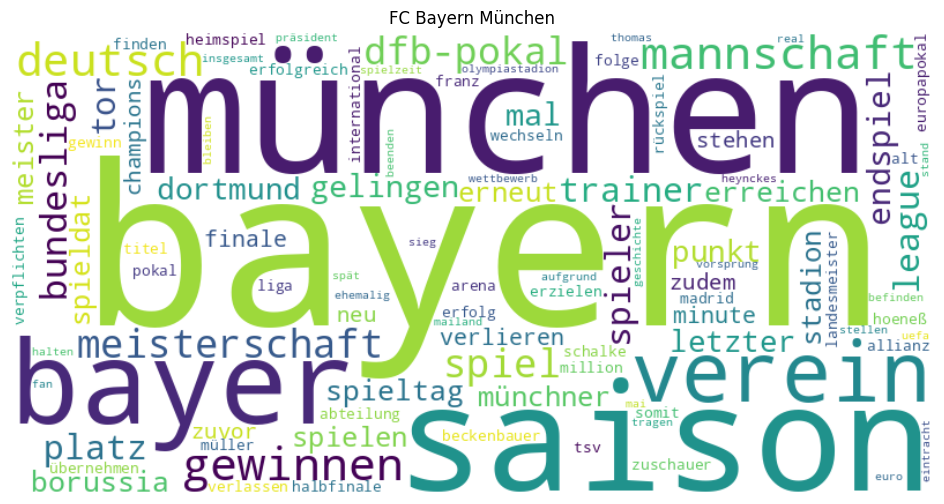

In [14]:
zeige_wortwolke(haeufigkeiten, titel="FC Bayern München")

--------------------------------------------

### 5. Schritt: Klassen bauen aus den vorherigen Schritten

- `def speichern` wird ergänzt
- `def laden_aus_json`wird ergänzt

In [21]:
# Klasse 1: Daten laden & verarbeiten
class VereinsNLP:
    def __init__(self, teams: list):
        self.teams = teams
        self.rohdaten = {}      # texte nach Schritt 1
        self.woerter = {}       # tokens nach Schritt 2
        self.haeufigkeiten = {} # counts nach Schritt 3

    def laden(self):
        self.rohdaten = lade_wiki_texte(self.teams)

    def verarbeiten(self):
        for team, text in self.rohdaten.items():
            w = bereinige_und_tokenisiere(text)
            self.woerter[team] = w
            self.haeufigkeiten[team] = zaehle_woerter(w)

    def speichern(self, pfad: str):
        import json
        with open(pfad, "w") as f:
            json.dump(self.haeufigkeiten, f, ensure_ascii=False, indent=2)

    def laden_aus_json(self, pfad: str):
        import json
        with open(pfad) as f:
            self.haeufigkeiten = json.load(f)


# Klasse 2: Anzeigen
class WolkenAnzeiger:
    def zeige(self, haeufigkeiten: dict, titel: str = ""):
        zeige_wortwolke(haeufigkeiten, titel)

### Klasse aufrufen

✓ FC Bayern München geladen (173624 Zeichen)
✓ Borussia Dortmund geladen (161378 Zeichen)


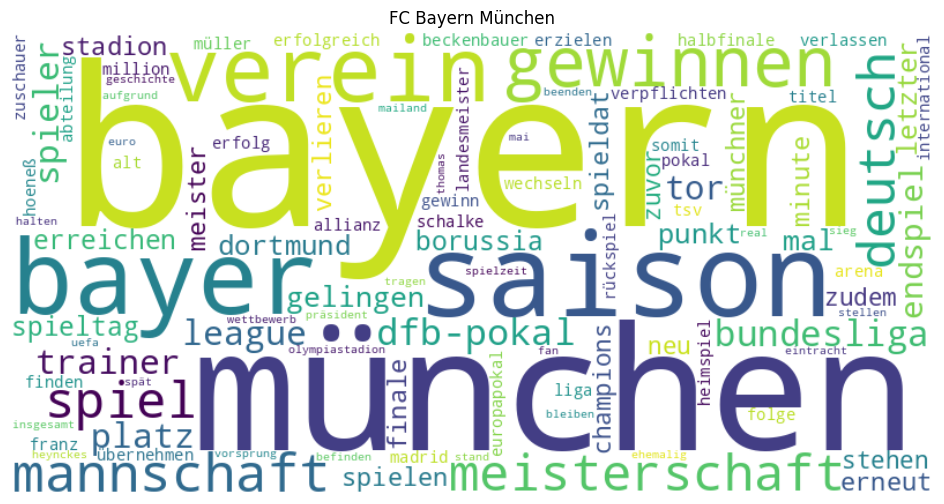

In [16]:
# Klasse testen im Notebook
pipeline = VereinsNLP(["FC Bayern München", "Borussia Dortmund"])
pipeline.laden()
pipeline.verarbeiten()
pipeline.speichern("haeufigkeiten.json")

# Anzeigen wie bisher
anzeiger = WolkenAnzeiger()
anzeiger.zeige(pipeline.haeufigkeiten["FC Bayern München"], titel="FC Bayern München")

-------------------------------------------

### Einbindung von Wortwolken, Clustering und RAG aus Wikipedia-Texten an Streamlit-UI

#### Online/Offline-Trennung

```
OFFLINE (einmalig, du führst es aus)        ONLINE (Streamlit, Nutzer sieht es)
────────────────────────────────────        ────────────────────────────────────
Wikipedia laden                             JSON laden
Preprocessing                               Filter anwenden
Clustering berechnen                        Wortwolke anzeigen
Embeddings für RAG erzeugen                 RAG-Suche ausführen
→ alles als Dateien speichern               → Dateien lesen, nie neu berechnen


```
data/
├── haeufigkeiten.json      ← Wortwolken
├── cluster_labels.json     ← Clustering-Ergebnisse
├── embeddings.npy          ← Vektoren für RAG
└── metadaten.json          ← Verein, Liga, Land → für Filter

#### Struktur der Datei metadaten.json (für den Filter)

```
{
  "FC Bayern München": {
    "münchen": 45,
    "bayern": 38,
    "saison": 21,
    "bundesliga": 18
  },
  "Borussia Dortmund": {
    "dortmund": 52,
    "signal": 31,
    "iduna": 28,
    "meister": 15
  }
}

#### Verschachtelte Dictionaries

```
# Äußeres Dictionary:
{
  "FC Bayern München": ...,   # Schlüssel → Verein
  "Borussia Dortmund": ...    # Schlüssel → Verein
}

# Inneres Dictionary (der Wert eines Vereins):
{
  "münchen": 45,    # Schlüssel → Wort, Wert → Häufigkeit
  "bayern": 38,
}

### Metadaten anlegen: Alle Bundesliga-Vereine beziehen

**Was passiert hier?**
Die Metadaten verknüpfen jeden Verein mit Liga und Land.
Diese Datei wird später in Streamlit für die Filter genutzt.
Sie wird einmalig manuell gepflegt und als JSON gespeichert.

**Wichtig:** Die Vereinsnamen müssen exakt den Wikipedia-Seitentiteln entsprechen.

In [ ]:
metadaten = {
    "FC Bayern München":        {"liga": "Bundesliga", "land": "Deutschland"},
    "Borussia Dortmund":        {"liga": "Bundesliga", "land": "Deutschland"},
    "Bayer 04 Leverkusen":      {"liga": "Bundesliga", "land": "Deutschland"},
    "RB Leipzig":               {"liga": "Bundesliga", "land": "Deutschland"},
    "Eintracht Frankfurt":      {"liga": "Bundesliga", "land": "Deutschland"},
    "VfB Stuttgart":            {"liga": "Bundesliga", "land": "Deutschland"},
    "SC Freiburg":              {"liga": "Bundesliga", "land": "Deutschland"},
    "1. FC Union Berlin":       {"liga": "Bundesliga", "land": "Deutschland"},
    "Borussia Mönchengladbach": {"liga": "Bundesliga", "land": "Deutschland"},
    "Werder Bremen":            {"liga": "Bundesliga", "land": "Deutschland"},
    "TSG 1899 Hoffenheim":      {"liga": "Bundesliga", "land": "Deutschland"},
    "FC Augsburg":              {"liga": "Bundesliga", "land": "Deutschland"},
    "VfL Bochum":               {"liga": "Bundesliga", "land": "Deutschland"},
    "1. FSV Mainz 05":          {"liga": "Bundesliga", "land": "Deutschland"},
    "VfL Wolfsburg":            {"liga": "Bundesliga", "land": "Deutschland"},
    "1. FC Heidenheim":         {"liga": "Bundesliga", "land": "Deutschland"},
    "FC St. Pauli":             {"liga": "Bundesliga", "land": "Deutschland"},
    "Holstein Kiel":            {"liga": "Bundesliga", "land": "Deutschland"},
}

import json
with open("metadaten.json", "w", encoding="utf-8") as f:
    json.dump(metadaten, f, ensure_ascii=False, indent=2)


print(f"✓ {len(metadaten)} Vereine gespeichert")

In [18]:
# Vereinsnamen aus Metadaten als Eingabe für die Pipeline nutzen
pipeline = VereinsNLP(list(metadaten.keys()))
pipeline.laden()
pipeline.verarbeiten()
pipeline.speichern("haeufigkeiten.json")

print("✓ Alle Wortwolken gespeichert")

✓ FC Bayern München geladen (173624 Zeichen)
✓ Borussia Dortmund geladen (161378 Zeichen)
✓ Bayer 04 Leverkusen geladen (53224 Zeichen)
✓ RB Leipzig geladen (54044 Zeichen)
✓ Eintracht Frankfurt geladen (102367 Zeichen)
✓ VfB Stuttgart geladen (115773 Zeichen)
✓ SC Freiburg geladen (51552 Zeichen)
✓ 1. FC Union Berlin geladen (60968 Zeichen)
✓ Borussia Mönchengladbach geladen (132812 Zeichen)
✓ Werder Bremen geladen (120598 Zeichen)
✓ TSG 1899 Hoffenheim geladen (51569 Zeichen)
✓ FC Augsburg geladen (61430 Zeichen)
✓ VfL Bochum geladen (53815 Zeichen)
✓ 1. FSV Mainz 05 geladen (80190 Zeichen)
✓ VfL Wolfsburg geladen (33441 Zeichen)
✓ 1. FC Heidenheim geladen (34347 Zeichen)
✓ FC St. Pauli geladen (108951 Zeichen)
✓ Holstein Kiel geladen (102715 Zeichen)
✓ Alle Wortwolken gespeichert


-----------------------------

### Aufruf der Classes erweitern auf gesamte Bundesliga

- metadaten.json einbinden

In [22]:
# Metadaten laden
import json
with open("metadaten.json", encoding="utf-8") as f:
    metadaten = json.load(f)

# Vereinsnamen als Liste an die Klasse übergeben
pipeline = VereinsNLP(list(metadaten.keys()))
pipeline.laden()
pipeline.verarbeiten()
pipeline.speichern("haeufigkeiten.json")

✓ FC Bayern München geladen (173624 Zeichen)
✓ Borussia Dortmund geladen (161378 Zeichen)
✓ Bayer 04 Leverkusen geladen (53224 Zeichen)
✓ RB Leipzig geladen (54044 Zeichen)
✓ Eintracht Frankfurt geladen (102367 Zeichen)
✓ VfB Stuttgart geladen (115773 Zeichen)
✓ SC Freiburg geladen (51552 Zeichen)
✓ 1. FC Union Berlin geladen (60968 Zeichen)
✓ Borussia Mönchengladbach geladen (132812 Zeichen)
✓ Werder Bremen geladen (120598 Zeichen)
✓ TSG 1899 Hoffenheim geladen (51569 Zeichen)
✓ FC Augsburg geladen (61430 Zeichen)
✓ VfL Bochum geladen (53815 Zeichen)
✓ 1. FSV Mainz 05 geladen (80190 Zeichen)
✓ VfL Wolfsburg geladen (33441 Zeichen)
✓ 1. FC Heidenheim geladen (34347 Zeichen)
✓ FC St. Pauli geladen (108951 Zeichen)
✓ Holstein Kiel geladen (102715 Zeichen)



------------------------------------------

### Simulation einer Pipeline mit main.py

✓ FC Bayern München geladen (173624 Zeichen)
✓ Borussia Dortmund geladen (161378 Zeichen)
✓ Bayer 04 Leverkusen geladen (53224 Zeichen)
✓ RB Leipzig geladen (54044 Zeichen)
✓ Eintracht Frankfurt geladen (102367 Zeichen)
✓ VfB Stuttgart geladen (115773 Zeichen)
✓ SC Freiburg geladen (51552 Zeichen)
✓ 1. FC Union Berlin geladen (60968 Zeichen)
✓ Borussia Mönchengladbach geladen (132812 Zeichen)
✓ Werder Bremen geladen (120598 Zeichen)
✓ TSG 1899 Hoffenheim geladen (51569 Zeichen)
✓ FC Augsburg geladen (61430 Zeichen)
✓ VfL Bochum geladen (53815 Zeichen)
✓ 1. FSV Mainz 05 geladen (80190 Zeichen)
✓ VfL Wolfsburg geladen (33441 Zeichen)
✓ 1. FC Heidenheim geladen (34347 Zeichen)
✓ FC St. Pauli geladen (108951 Zeichen)
✓ Holstein Kiel geladen (102715 Zeichen)


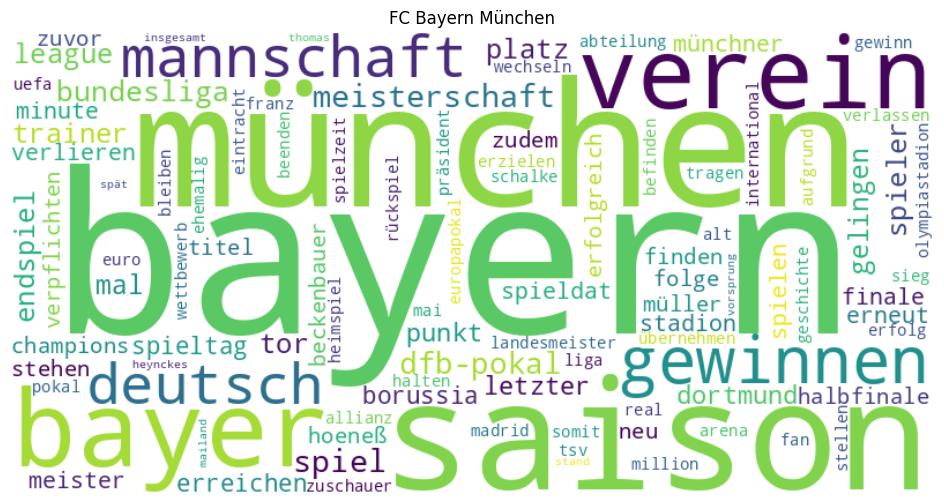

In [23]:
# ── SIMULATION: main.py ──────────────────────────────
# So würde der Code später als .py-Datei aussehen

# 1. Metadaten laden
import json
with open("metadaten.json", encoding="utf-8") as f:
    metadaten = json.load(f)

# 2. Pipeline aufbauen und ausführen
pipeline = VereinsNLP(list(metadaten.keys()))
pipeline.laden()
pipeline.verarbeiten()
pipeline.speichern("haeufigkeiten.json")

# 3. Wortwolke für einen Verein anzeigen
anzeiger = WolkenAnzeiger()
anzeiger.zeige(pipeline.haeufigkeiten["FC Bayern München"], titel="FC Bayern München")

#### Umsetzung in Streamlit

In [31]:
# Einmalig beim Start – lädt aus JSON, nicht neu von Wikipedia
nlp = VereinsNLP([])
nlp.laden_aus_json("haeufigkeiten.json")

# Filter
verein = st.selectbox("Verein", list(nlp.haeufigkeiten.keys()))
liga   = st.selectbox("Liga", ["Bundesliga", "La Liga", ...])

# Anzeige
anzeiger = WolkenAnzeiger()
anzeiger.zeige(nlp.haeufigkeiten[verein], titel=verein)

FileNotFoundError: [Errno 2] No such file or directory: 'haeufigkeiten.json'